In [1]:
import nibabel as nib
import matplotlib.pyplot as plt

In [2]:
img = nib.load("../data/BraTS/BraTS20_Training_001/BraTS20_Training_001_flair.nii")
data = img.get_fdata()

print(data.shape)

(240, 240, 155)


(np.float64(-0.5), np.float64(239.5), np.float64(239.5), np.float64(-0.5))

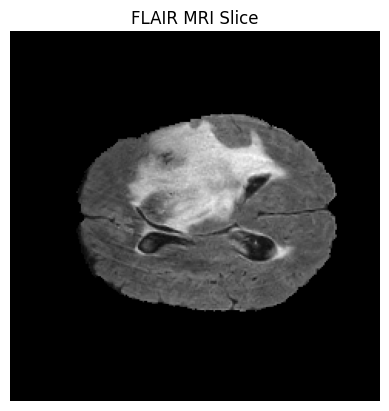

In [3]:
slice_index = 80

plt.imshow(data[:,:, slice_index], cmap = "gray")
plt.title("FLAIR MRI Slice")
plt.axis("off")

In [4]:
print(img.header.get_zooms()) # meaning 1mm voxel spacing

(np.float32(1.0), np.float32(1.0), np.float32(1.0))


First Preprocessing Experiment

TorchIO preprocssing

In [10]:
import torchio as tio

In [13]:
subject = tio.Subject(
    flair = tio.ScalarImage("../data/BraTS/BraTS20_Training_001/BraTS20_Training_001_flair.nii"),
    label = tio.LabelMap("../data/BraTS/BraTS20_Training_001/BraTS20_Training_001_seg.nii")
)

transform = tio.Compose([
    tio.ZNormalization(),
    tio.Resample(1),
])

processed = transform(subject)
print(processed)

Subject(Keys: ('flair', 'label'); images: 2)


Image Registration | Advanced Normalization Tools (ANTs)

Goal is to align T1 to FLAIR

In [14]:
import ants

In [15]:
fixed = ants.image_read("../data/BraTS/BraTS20_Training_001/BraTS20_Training_001_flair.nii")
moving = ants.image_read("../data/BraTS/BraTS20_Training_001/BraTS20_Training_001_t1.nii")

reg = ants.registration(
    fixed = fixed,
    moving = moving,
    type_of_transform = "Rigid" # Rigid Registration
)

aligned = reg["warpedmovout"] 